# **Executive Summary**

**1. Summary (Context):**
- The app market is driven by high competition in mass segments, with a few high-opportunity categories and smaller niche markets.
- Growth is mainly influenced by low entry barrier (free model) and strong product value (often reflected by size & features).
- There are clear trade-offs across key levers:
    + Size: Accessibility vs feature richness
    + Pricing: Growth vs upfront revenue
    + Updates: Frequency vs execution quality
- User feedback shows a gap between ratings and real sentiment, highlighting hidden experience issues.
- Overall, success depends on balancing acquisition (installs) and retention (user satisfaction).

**2. Assumptions:**
- Installs represent market demand and scalability.
- Ratings & sentiment reflect user satisfaction and true experience.
- App size acts as a proxy for product complexity and value.
- Pricing impacts user acquisition friction and expectation level.
- Update frequency signals product maintenance quality, but execution matters more.
- Market is skewed toward free, mass-market apps, with niche segments behaving differently.

**3. Insight & Action:**
***Insight 1: Growth = Low Friction + High Value***
  + Free apps with strong value dominate installs.
***Action:***
  + Default to free model + backend monetization
  + Focus on core value delivery to drive adoption

***Insight 2: Sweet Spot for Scale (Product Design)***
  + Mid-size apps (30–100MB) balance installs and user satisfaction.
***Action:***
  + Optimize size for mass accessibility
  + Avoid over-simplifying (low value) or over-complexity (high barrier)

***Insight 3: Competition Strategy by Market Type***
  + Mass market = high scale but high competition
  + Niche market = lower competition but limited growth
***Action:***
  + Enter mass market only with clear differentiation
  + Use niche markets for focused, sustainable growth

**Insight 4: *Experience* > Pricing** *italicized text*
  + Price has limited impact on rating; expectations matter more.
***Action:***
  + Compete on UX, product quality, and reliability
  + Only use paid model for clear niche or high-intent users

Insight 5: Hidden Risk in User Feedback ***italicized text***
  + High ratings can mask negative sentiment and low loyalty.
***Action:***
  + Track sentiment alongside rating
  + Fix core pain points (bugs, UX, value gaps) early

***Insight 6: Execution Quality Drives Retention***
  + Updates help, but poor releases create negative spikes.
***Action:***
  + Prioritize QA, stability, and onboarding experience
  + Align marketing promise with actual product delivery

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
from google.colab import drive
os.makedirs('content', exist_ok=True) # Create the 'content' directory if it doesn't exist
drive.mount('content/drive')

Mounted at content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **A0. Dataset Preparation:**

In [6]:
df_play_store = pd.read_csv('/content/drive/MyDrive/EDA/01. Playstore/Play Store Data.csv')
df_user_review = pd.read_csv('/content/drive/MyDrive/EDA/01. Playstore/User Reviews.csv')

In [7]:
df_play_store.head(5)
# print(df_user_review.head(5))

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
df_user_review.head(5)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


# **A1. Play Store Table:**

In [9]:
print("The row number of the playstore dataset is ",df_play_store.shape[0])
print("The col number of the playstore dataset is ",df_play_store.shape[1])

The row number of the playstore dataset is  10841
The col number of the playstore dataset is  13


In [10]:
df_play_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [11]:
df_play_store.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [12]:
print("Duplicated values in Playstore are ", df_play_store.duplicated().sum())
print("Null values in Playstore are ",df_play_store.isnull().sum())

Duplicated values in Playstore are  483
Null values in Playstore are  App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [13]:

print("The col list of Playstore is: \n", df_play_store.columns.tolist())

The col list of Playstore is: 
 ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [14]:
df_play_store.columns = df_play_store.columns.str.lower()
df_play_store.columns = df_play_store.columns.str.replace(" ","_")
# df_play_store.colums = df_play_store.colums.str.lower().str.replace(" ","_")
df_play_store.columns.to_list()

['app',
 'category',
 'rating',
 'reviews',
 'size',
 'installs',
 'type',
 'price',
 'content_rating',
 'genres',
 'last_updated',
 'current_ver',
 'android_ver']

In [15]:
df_play_store[df_play_store['type'] != 'Free'].head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8M,"100,000+",Paid,$4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39M,"100,000+",Paid,$4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
290,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8M,"100,000+",Paid,$4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39M,"100,000+",Paid,$4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,Varies with device,"100,000+",Paid,$3.99,Everyone,Communication,"July 5, 2018",7.5.3.20547,4.1 and up


In [16]:
df_play_store[df_play_store['price'] == 'Everyone'] = 0
df_play_store['price'] = df_play_store['price'].astype('string')
def drop_dollar_sign(self):
  if self.startswith('$'):
    return float(self[1:])
  else:
    return float(self)

df_play_store['price'] = df_play_store['price'].apply(lambda x: drop_dollar_sign(x))
# df_play_store[df_play_store['type'] != 'Free'].head(5)

In [17]:
df_play_store['price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [18]:
df_play_store['installs']= df_play_store['installs'].astype('string')
df_play_store['installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: string

In [19]:
# df_play_store['Installs'].unique()
def drop_plus_sign(self):
  if self.endswith('+') and "," in self:
    return int(self[:-1].replace(',',''))
  elif self.endswith('+'):
    return int(self[:-1])
  else:
    return int(self)
df_play_store['installs'] = df_play_store['installs'].apply(lambda x: drop_plus_sign(x))

In [20]:
df_play_store['installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [21]:
# df_play_store.head(5)
df_play_store['size'] = df_play_store['size'].astype('string')
# df_play_store['size'].unique()
def drop_no_size(self):
  if self.endswith("M") or (self.endswith("M") and "." in self):
    return int(self[:-1].replace(".","")) * 100000
  elif self.endswith("k"):
    return int(self[:-1].replace(".","")) * 1000
  elif self == 'Varies with device':
    return 0
  else:
    return int(self)
df_play_store['size'] = df_play_store['size'].apply(lambda x: drop_no_size(x))
df_play_store.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1900000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2500000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [22]:
print(df_play_store.iloc[234])

app               TurboScan: scan documents and receipts in PDF
category                                               BUSINESS
rating                                                      4.7
reviews                                                   11442
size                                                    6800000
installs                                                 100000
type                                                       Paid
price                                                      4.99
content_rating                                         Everyone
genres                                                 Business
last_updated                                     March 25, 2018
current_ver                                               1.5.2
android_ver                                          4.0 and up
Name: 234, dtype: object


In [23]:
df_play_store['rating'].fillna(df_play_store['rating'].mean(),inplace = True)
df_play_store['type'].fillna(df_play_store['type'].mode()[0], inplace=True)
df_play_store['size'].fillna(df_play_store['size'].mode()[0], inplace=True)
df_play_store['content_rating'].fillna(df_play_store['content_rating'].mode()[0],inplace = True)
df_play_store['current_ver'].fillna('Varies with device', inplace=True)
df_play_store['android_ver'].fillna('Varies with device', inplace=True)
df_play_store.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1900000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2500000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [24]:
df_play_store['last_updated'] = pd.to_datetime(df_play_store['last_updated'], errors= 'coerce')
df_play_store['month'] = df_play_store['last_updated'].dt.month
df_play_store['year'] = df_play_store['last_updated'].dt.year

In [25]:
# print(df_play_store.duplicated().sum()) #tổng dòng dup
# print(df_play_store.count())
df_play_store_clean = df_play_store.drop_duplicates()

In [26]:
df_play_store_clean = df_play_store_clean.drop(10472)
df_play_store_clean.count()

,0
app,10357
category,10357
rating,10357
reviews,10357
size,10357
installs,10357
type,10357
price,10357
content_rating,10357
genres,10357


# **A2. User Review Table:**

In [27]:
df_user_review = pd.read_csv('/content/drive/MyDrive/EDA/01. Playstore/User Reviews.csv')

In [28]:
df_user_review.columns = df_user_review.columns.str.lower()
df_user_review.columns = df_user_review.columns.str.replace(" ","_")

In [29]:
df_user_review.head(5)

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [30]:
df_user_review.describe()

,sentiment_polarity,sentiment_subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


In [31]:
df_user_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   app                     64295 non-null  object 
 1   translated_review       37427 non-null  object 
 2   sentiment               37432 non-null  object 
 3   sentiment_polarity      37432 non-null  float64
 4   sentiment_subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [32]:
df_user_review.head(5)
# df_user_review[df_user_review['sentiment'].isna() == True]
df_user_review['sentiment'] = df_user_review['sentiment'].fillna('No Comment')
df_user_review.head(5)

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,No Comment,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [33]:
df_user_review.head(5)
# df_user_review[df_user_review['translated_review'].isna() == True]
df_user_review['translated_review'] = df_user_review['translated_review'].fillna('No Comment')
df_user_review.head(5)

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,No Comment,No Comment,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [34]:
# df_user_review['sentiment_polarity'] = df_user_review['sentiment_polarity'].fillna(df_user_review['sentiment_polarity'].mean(),inplace = True)
df_user_review['sentiment_polarity'].fillna(df_user_review['sentiment_polarity'].mean(),inplace = True)
df_user_review['sentiment_subjectivity'].fillna(df_user_review['sentiment_subjectivity'].mean(),inplace = True)
df_user_review.head(5)

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462
2,10 Best Foods for You,No Comment,No Comment,0.182146,0.492704
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000


In [35]:
df_user_review_clean = df_user_review.drop_duplicates()
df_user_review_clean.count()

,0
app,30679
translated_review,30679
sentiment,30679
sentiment_polarity,30679
sentiment_subjectivity,30679


# **B. Analysis:**

In [36]:
df_play_store_clean.to_csv('data_playstore.csv',index = False)
df_user_review_clean.to_csv('data_user_review.csv', index = False)

In [37]:

category_performance = df_play_store_clean.groupby('category').agg({'rating':'mean','installs':'sum','app':'count'}).sort_values(by = 'app', ascending = False).reset_index()
category_performance

,category,rating,installs,app
0,FAMILY,4.191171,10041692505,1943
1,GAME,4.277513,31544024415,1121
2,TOOLS,4.066018,11452771915,843
3,BUSINESS,4.135212,863664865,427
4,MEDICAL,4.184752,42204177,408
5,PRODUCTIVITY,4.199916,12463091369,407
6,PERSONALIZATION,4.305212,2074494782,388
7,LIFESTYLE,4.113429,534823539,373
8,COMMUNICATION,4.157889,24152276251,366
9,FINANCE,4.135073,770348734,360


In [38]:
category_performance.columns = ['category','avg_rating','sum_installation','app_count']

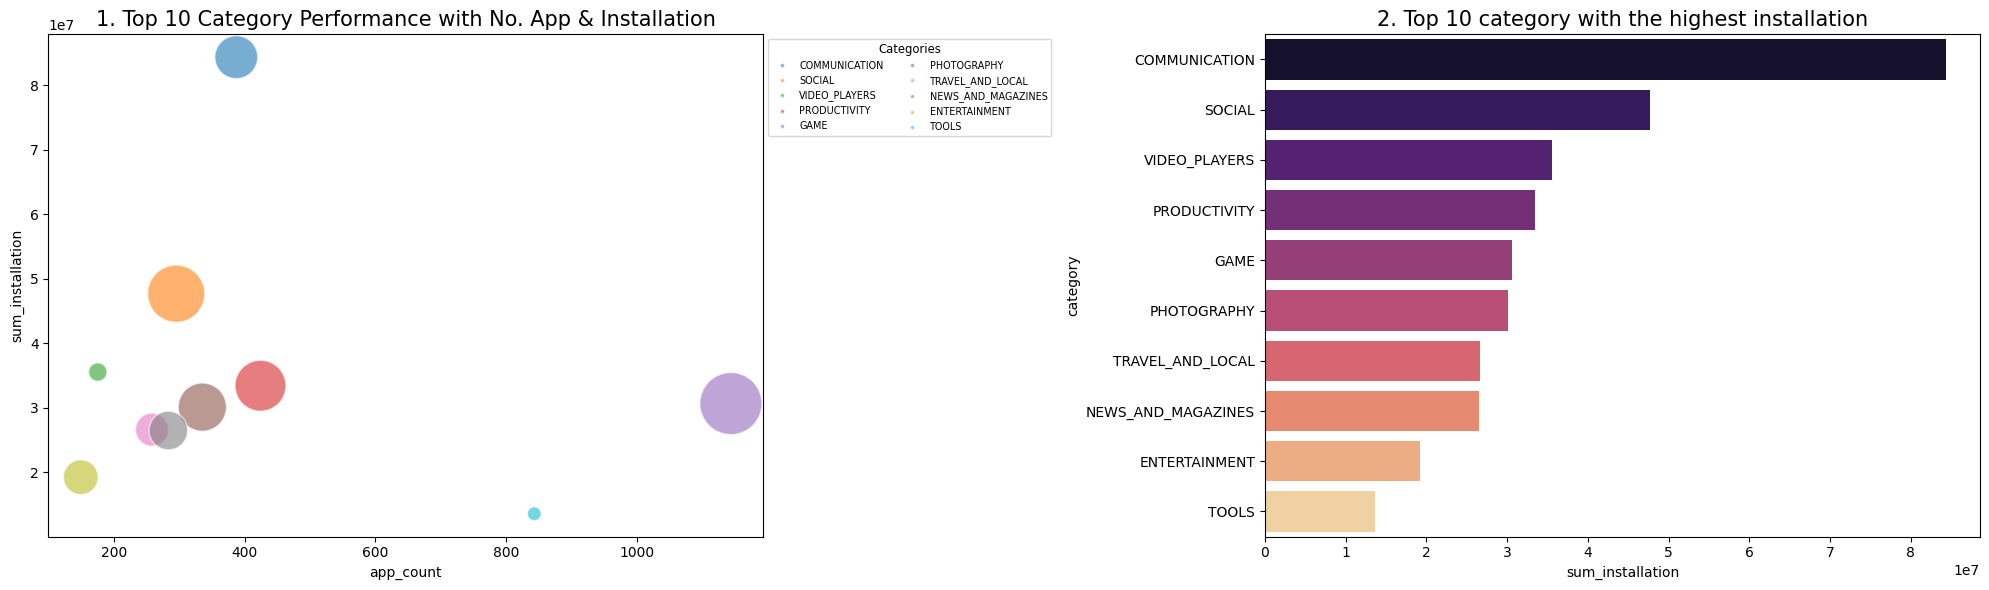

In [39]:

category_performance = df_play_store.groupby('category').agg({
    'app': 'count',
    'installs': 'mean',
    'rating': 'mean'
}).reset_index()

category_performance.columns = ['category', 'app_count', 'sum_installation', 'avg_rating']


fig, axes = plt.subplots(1, 2, figsize=(20, 6))


sns.scatterplot(
    data=category_performance.sort_values('sum_installation',ascending=False).head(10),
    x='app_count',
    y='sum_installation',
    size='avg_rating',
    hue='category',
    ax=axes[0],
    sizes=(100, 2000),
    alpha=0.6
)

handles, labels = axes[0].get_legend_handles_labels()
num_categories = 10
axes[0].set_title('1. Top 10 Category Performance with No. App & Installation', fontsize=15)
axes[0].legend(
    handles[1:num_categories+1],
    labels[1:num_categories+1],
    title='Categories',
    fontsize='x-small',
    title_fontsize='small',
    ncol=2,
    markerscale=0.5,
    loc='upper left',
    bbox_to_anchor=(1, 1)
)


top_10 = category_performance.sort_values('sum_installation', ascending=False).head(10)
sns.barplot(
    data=top_10,
    x='sum_installation',
    y='category',
    palette='magma',
    ax=axes[1]
)
axes[1].set_title('2. Top 10 category with the highest installation', fontsize=15)

plt.tight_layout()
plt.show()

  **1. Summary**
  - The market splits into 3 clear groups: high competition, high opportunity, and niche markets.
  - Some categories have many apps but still high installs => large but very competitive.
  - Others show low competition but strong installs => best entry opportunities.
  Niche categories offer balanced competition and stable demand.

  **2. Assumptions**
  - Average installs reflect real user demand per category.
  - Number of apps represents competition level.
  - High installs + low apps indicate unsatisfied demand.
  - High installs + high apps require strong marketing and differentiation to win.

  **3. Insight & Action**

  A. High Apps & High Installs (e.g. Game, Tools)
  - Insight: Large market but extremely competitive.
  - Action: Enter only if having strong budget + clear differentiation.

  B. Low Apps & High Installs (e.g. Communication, Social)
  - Insight: Best opportunity with high demand and lower competition.
  - Action: Prioritize entering these categories to maximize reach and growth.

  C. Niche Market (e.g. Photography, Travel)
  - Insight: Moderate competition with stable demand.
  - Action: Suitable for small teams to build sustainable products without heavy competition.

In [40]:
df_play_store_clean.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,1900000,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,1.0,2018.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,1.0,2018.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700000,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.0,2018.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,2500000,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,6.0,2018.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800000,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,6.0,2018.0


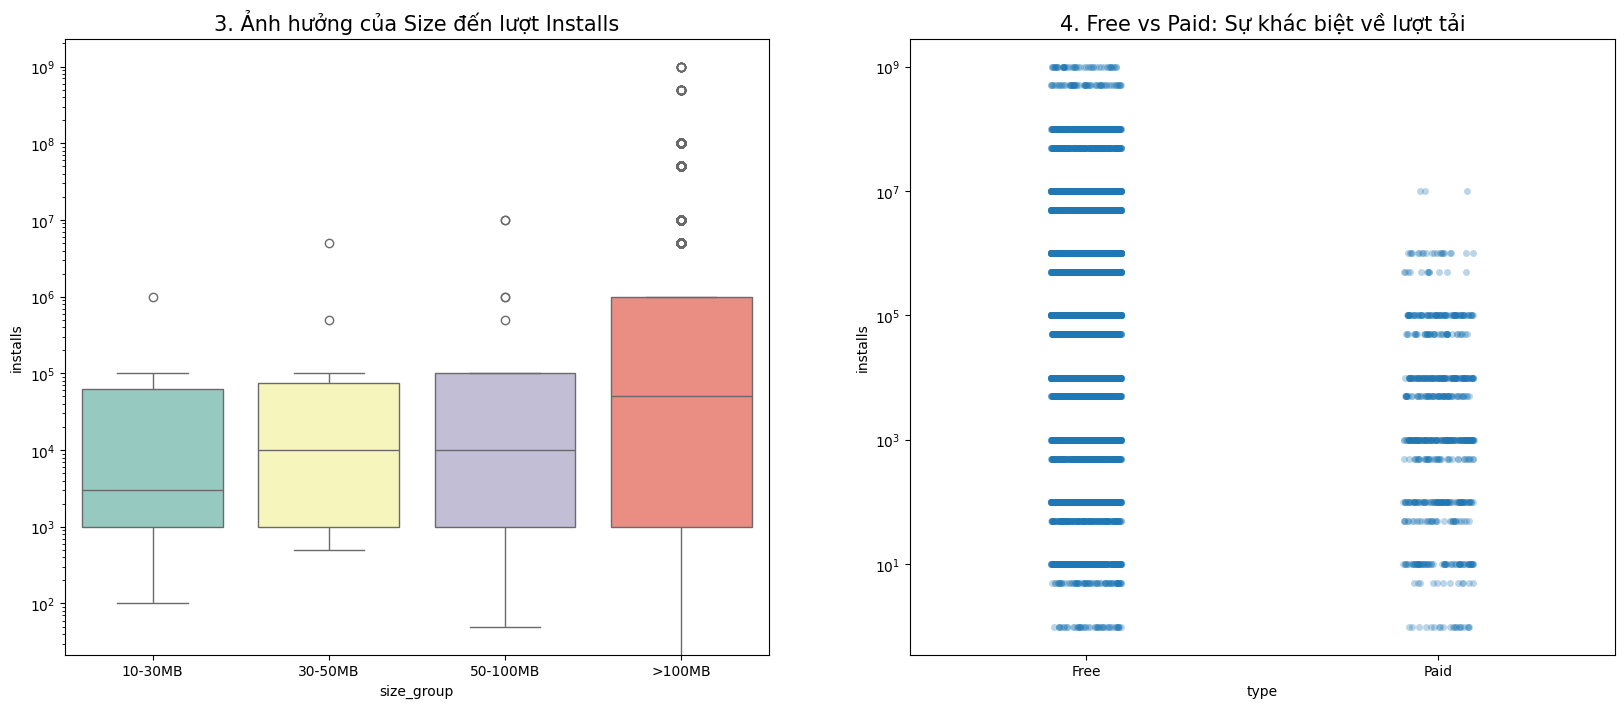

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


df_play_store_clean['size_group'] = pd.cut(df_play_store_clean['size'],
                        #  bins=[0, 10e6, 30e6, 50e6, 100e6, np.inf],
                        #  labels=['<10MB', '10-30MB', '30-50MB', '50-100MB', '>100MB'])
                        bins = [10*1024, 30*1024, 50*1024, 100*1024, float('inf')],
                        labels = ['10-30MB', '30-50MB', '50-100MB', '>100MB']
)

sns.boxplot(data=df_play_store_clean, x='size_group', y='installs', palette='Set3', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('3. Ảnh hưởng của Size đến lượt Installs', fontsize=15)


sns.stripplot(data=df_play_store_clean, x='type', y='installs', jitter=True, alpha=0.3, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('4. Free vs Paid: Sự khác biệt về lượt tải', fontsize=15)

plt.show()

**1. Summary**
- Chart 3: Larger app size tends to link with higher installs, but performance becomes more volatile at bigger sizes.
- Chart 4: Free apps dominate installs, while paid apps remain at low scale.
- Overall, installs are driven by a mix of product value (size proxy) and pricing friction.

**2. Assumptions**
- App size reflects feature richness and perceived value.
- Pricing model impacts user acquisition barrier.
- High installs indicate strong product-market fit.
- Variance suggests inconsistent execution quality across apps.

**3. Insight & Action**

Insight 1: Value drives installs (Chart 3)
- Larger apps often deliver higher value but with higher risk.
- Action: Build for strong core value, not just optimize for smaller size.

Insight 2: Friction limits scale (Chart 4)
- Paid apps face strong barriers to adoption.
- Action: Use free entry model to maximize growth.

Insight 3: Best model = Free + High Value
- Top-performing apps combine low friction (free) with high-value experience (often larger size).
- Action: Mass market: Free + optimized size (<100MB) High-end product (game/platform): Free + accept larger size. Niche tools: Paid possible, but limited scale

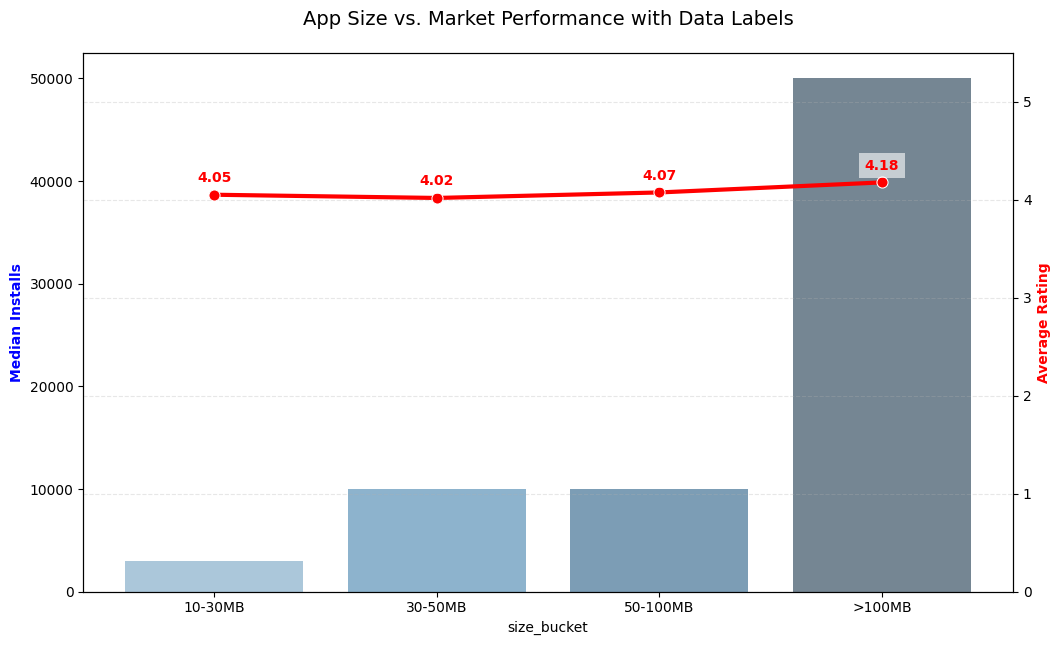

In [42]:
bins = [10*1024, 30*1024, 50*1024, 100*1024, float('inf')]
labels = ['10-30MB', '30-50MB', '50-100MB', '>100MB']

df_play_store_clean['size_bucket'] = pd.cut(df_play_store_clean['size'], bins=bins, labels=labels)


size_analysis = df_play_store_clean.groupby('size_bucket').agg({
    'installs': 'median',
    'rating': 'mean'
}).reset_index()


fig, ax1 = plt.subplots(figsize=(12, 7))


sns.barplot(data=size_analysis, x='size_bucket', y='installs', ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('Median Installs', color='blue', fontweight='bold')


ax2 = ax1.twinx()
line = sns.lineplot(data=size_analysis, x='size_bucket', y='rating', ax=ax2,
                    color='red', marker='o', linewidth=3, markersize=8)
ax2.set_ylabel('Average Rating', color='red', fontweight='bold')
ax2.set_ylim(0, 5.5)


for i in range(len(size_analysis)):

    x_val = i
    y_val = size_analysis['rating'].iloc[i]

    ax2.text(x_val, y_val + 0.1, f'{y_val:.2f}',
             color='red', fontweight='bold', ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.title('App Size vs. Market Performance with Data Labels', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

1. Summary:
- "30–50MB" (Sweet Spot): Highest installs with strong ratings => best balance.
- ">100MB": Highest ratings but lowest installs => high quality but limited reach.
- "<10MB": Easy to download but lowest ratings => weaker user experience.
- Overall, there is a trade-off between accessibility (size) and user satisfaction (quality).

2. Assumptions:
- App size reflects feature depth and product quality.
- Ratings represent user satisfaction after usage.
- Installs indicate ease of adoption and market reach.
- Larger size creates download friction, especially for new users.

3. Insight & Action:

Insight 1: Sweet Spot drives both growth & satisfaction
  + Mid-size apps achieve strong installs and high ratings.
Action:
  + Optimize product to stay within 30–50MB when possible.

Insight 2: High quality <> high adoption
  + Large apps (>100MB) deliver great experience but face entry barriers.
Action:
  + Strengthen value communication (features, graphics)
  + Justify why the app is worth the download

Insight 3: Small size may hurt experience
  + Very small apps often lack depth => lower ratings.
Action:
  + Avoid over-optimizing size at the cost of core features & UX

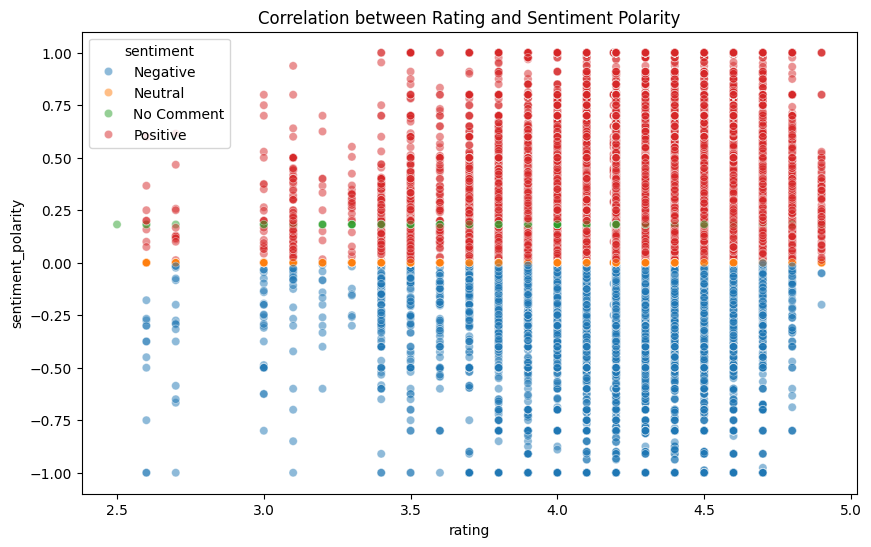

category
COMICS                 0.435434
EVENTS                 0.367940
AUTO_AND_VEHICLES      0.338157
PARENTING              0.307912
EDUCATION              0.286455
HEALTH_AND_FITNESS     0.285705
FOOD_AND_DRINK         0.278983
WEATHER                0.267291
MAPS_AND_NAVIGATION    0.255498
PERSONALIZATION        0.251272
MEDICAL                0.241369
LIBRARIES_AND_DEMO     0.238299
BOOKS_AND_REFERENCE    0.235533
ART_AND_DESIGN         0.231683
HOUSE_AND_HOME         0.224205
LIFESTYLE              0.221498
PHOTOGRAPHY            0.221070
TOOLS                  0.213428
TRAVEL_AND_LOCAL       0.199702
BEAUTY                 0.199301
SHOPPING               0.193622
BUSINESS               0.193431
PRODUCTIVITY           0.187126
SPORTS                 0.180122
FINANCE                0.176951
COMMUNICATION          0.176230
DATING                 0.169211
NEWS_AND_MAGAZINES     0.151610
ENTERTAINMENT          0.137508
VIDEO_PLAYERS          0.137340
FAMILY                 0.125438

In [43]:

merged_df = pd.merge(df_play_store_clean, df_user_review_clean, on='app', how='inner')


plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='rating', y='sentiment_polarity', hue='sentiment', alpha=0.5)
plt.title('Correlation between Rating and Sentiment Polarity')
plt.show()


category_sentiment = merged_df.groupby('category')['sentiment_polarity'].mean().sort_values(ascending=False)
print(category_sentiment)

--- The list of category summary ---


,category,sentiment_polarity,rating,total_apps
0,COMICS,0.435434,4.248315,5
1,EVENTS,0.367940,4.330864,7
2,AUTO_AND_VEHICLES,0.338157,4.578767,9
3,PARENTING,0.307912,4.257303,11
4,EDUCATION,0.286455,4.261219,31
5,HEALTH_AND_FITNESS,0.285705,4.436364,47
6,FOOD_AND_DRINK,0.278983,4.371596,20
7,WEATHER,0.267291,4.279399,6
8,MAPS_AND_NAVIGATION,0.255498,4.322000,11
9,PERSONALIZATION,0.251272,4.335000,44


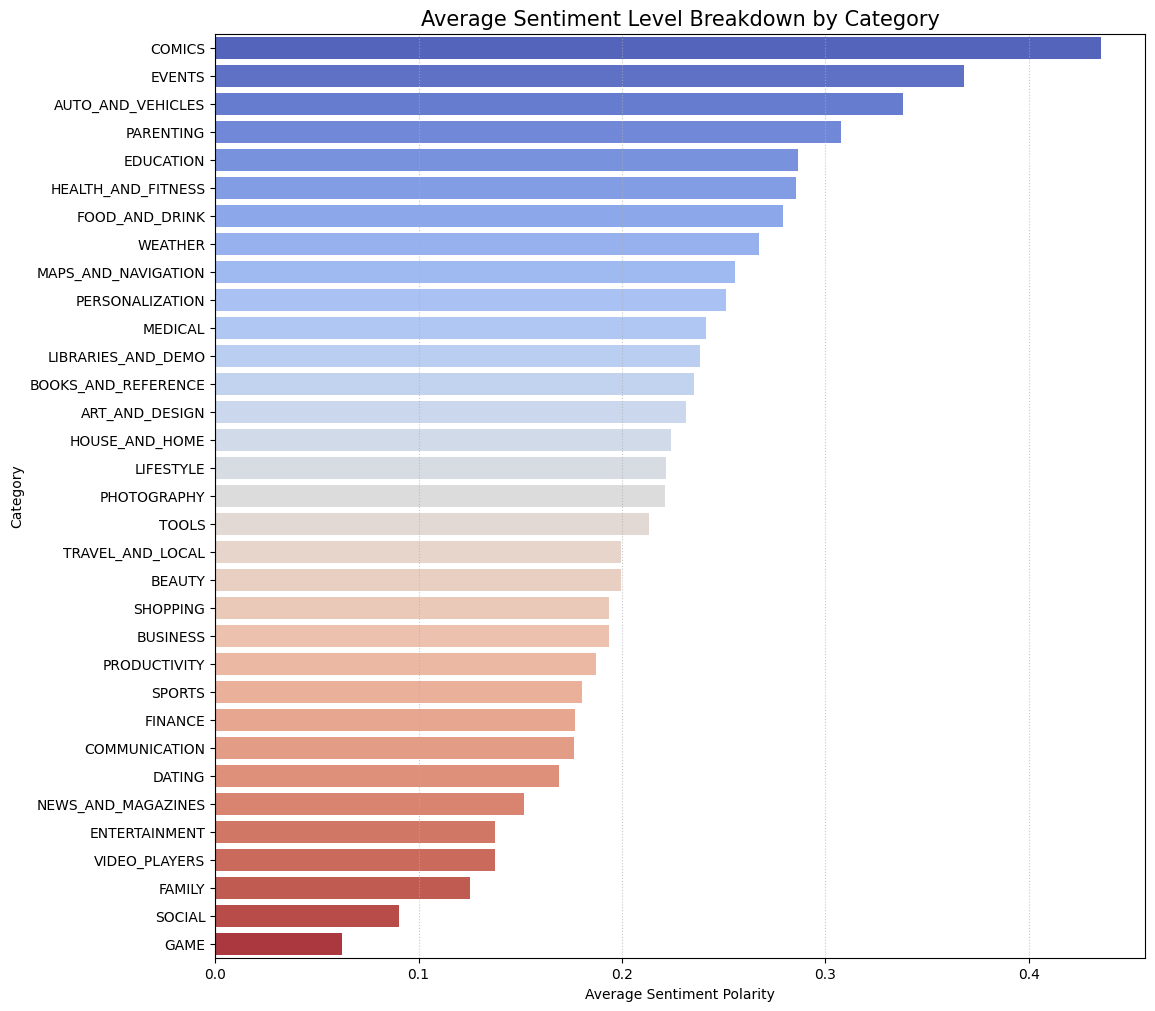

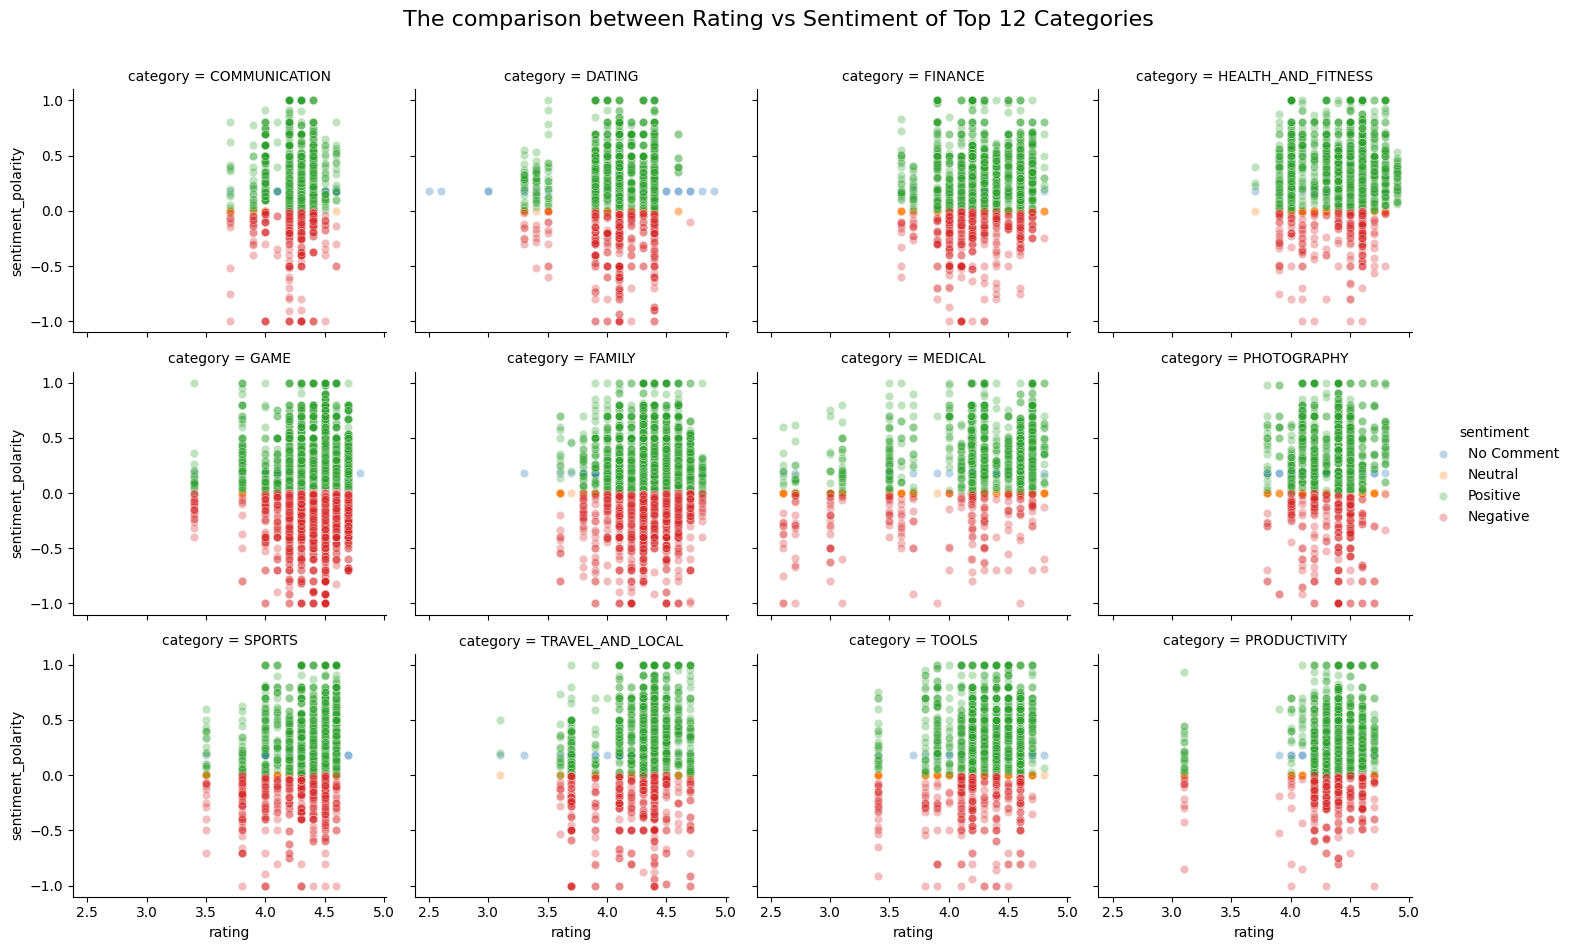

In [44]:

merged_df = pd.merge(df_play_store_clean, df_user_review_clean, on='app', how='inner')

category_summary = merged_df.groupby('category').agg({
    'sentiment_polarity': 'mean',
    'rating': 'mean',
    'app': 'nunique'
}).rename(columns={'app': 'total_apps'}).sort_values(by='sentiment_polarity', ascending=False).reset_index()


print("--- The list of category summary ---")
display(category_summary)


plt.figure(figsize=(12, 12))
sns.barplot(data=category_summary.reset_index(),
            x='sentiment_polarity',
            y='category',
            palette='coolwarm')
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Average Sentiment Level Breakdown by Category', fontsize=15)
plt.xlabel('Average Sentiment Polarity')
plt.ylabel('Category')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.show()


top_12_cats = merged_df['category'].value_counts().nlargest(12).index
df_subset = merged_df[merged_df['category'].isin(top_12_cats)]

g = sns.FacetGrid(df_subset, col="category", col_wrap=4, height=3, aspect=1.2, hue='sentiment')
g.map(sns.scatterplot, "rating", "sentiment_polarity", alpha=0.3)
g.add_legend()
g.fig.suptitle('The comparison between Rating vs Sentiment of Top 12 Categories', fontsize=16, y=1.05)
plt.show()

1. Summary:
- Some categories show high ratings but low sentiment (e.g. Game).
- Others maintain both high sentiment and positive experience (e.g. Education, Health).
- Certain essential categories have lower sentiment despite decent ratings (e.g. Social, Finance).
Overall, there is a gap between what users rate and what they actually feel.

2. Assumptions:
- Rating reflects overall satisfaction score.
- Sentiment reflects true user emotions in feedback.
- Users may rate high but still leave negative comments.
- Essential apps may retain users despite poor experience due to lack of alternatives.

3. Insight & Action:

Insight 1: High rating does not mean good experience (Game)
   + Users rate high but complain frequently => low loyalty.
Action:
   + Focus on fixing pain points (ads, bugs, difficulty) to improve retention.

Insight 2: Positive-use categories drive better sentiment
   + Categories like Education and Health show genuinely positive user  experience.
Action:
   + Invest in these areas for sustainable engagement and brand trust.

Insight 3: Essential apps = hidden dissatisfaction
   + Users continue using despite negative sentiment => low switching options.
Action:
   + Improve UX to reduce silent frustration and churn risk.

Insight 4: Rating vs Sentiment gap = risk signal
   + Negative sentiment even at high ratings indicates experience issues or forced rating behavior.
Action:
   + Monitor sentiment alongside rating to detect hidden product problems early.

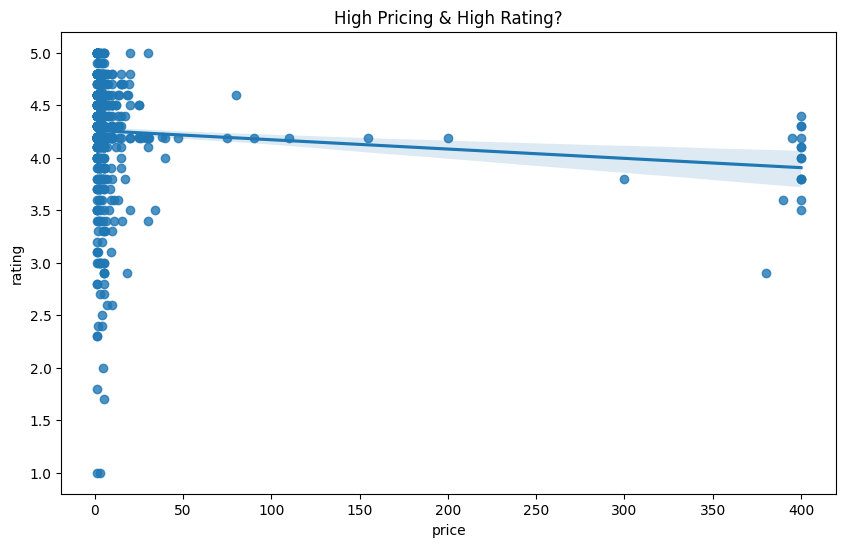

In [45]:
paid_apps = df_play_store_clean[df_play_store_clean['type'] == 'Paid']

plt.figure(figsize=(10, 6))
sns.regplot(data=paid_apps, x='price', y='rating')
plt.title('High Pricing & High Rating?')
plt.show()

1. Summary:
- Slight negative relationship between price and rating.
- Most apps are low-priced with mid-to-high ratings.
- A few high-price apps exist but do not achieve better ratings.
- Overall, pricing does not strongly drive rating performance.

2. Assumptions:
- Rating reflects user satisfaction vs expectation.
- Price sets user expectations before usage.
- Dataset is skewed toward low-price apps.
- High-price apps often belong to different segments (niche / enterprise).

3. Insight & Action:
Insight 1: Higher price does not improve rating
  + Expensive apps do not show better user satisfaction.
Action:
  + Focus on product quality and UX, not pricing strategy.

Insight 2: Market is dominated by low-price apps
  + Most insights are driven by affordable apps.
Action:
  + Benchmark performance within relevant price segments, not overall.

Insight 3: High-price apps = niche and unstable performance
  + Few high-price apps with inconsistent ratings.
Action:
  + Avoid direct comparison; define clear target segment and value proposition.

Insight 4: Expectation gap drives rating
  + Higher price increases expectations => easier to disappoint users.
Action:
  + If pricing higher, ensure strong value delivery and user support.

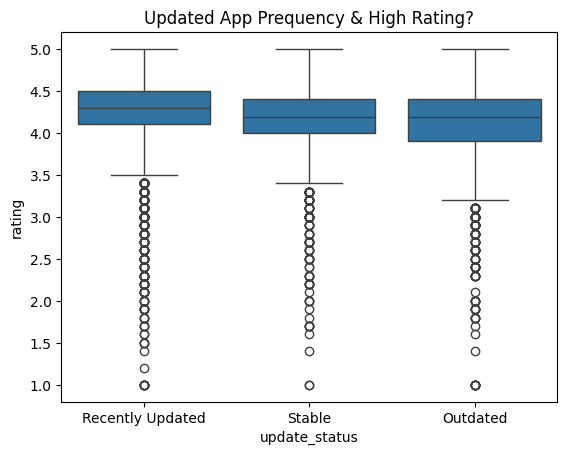

In [46]:
max_date = df_play_store_clean['last_updated'].max()
df_play_store_clean['days_since_update'] = (max_date - df_play_store_clean['last_updated']).dt.days


bins = [0, 180, 360, float('inf')]
labels = ['Recently Updated', 'Stable', 'Outdated']
df_play_store_clean['update_status'] = pd.cut(df_play_store_clean['days_since_update'], bins=bins, labels=labels)

sns.boxplot(data=df_play_store_clean, x='update_status', y='rating')
plt.title('Updated App Prequency & High Rating?')
plt.show()

1. Summary:
- Recently updated apps have slightly higher median ratings (~4.3).
- Stable and outdated apps show slightly lower ratings (~4.2).
- Rating distribution is similar across groups, with consistent spread.
- All groups contain many low-rating outliers, including recently updated apps.

2. Assumptions:
- Update frequency reflects product maintenance and improvement effort.
- Ratings capture user response to both stability and recent changes.
- Outliers indicate negative user experiences (e.g. bugs, UX issues).
- Some apps remain stable without updates due to simple or mature functionality.

3. Insight & Action:
Insight 1: Frequent updates support higher ratings
  + More recent updates correlate with better user satisfaction.
Action:
  + Maintain regular update cycles to sustain product quality.

Insight 2: Updates alone do not guarantee success
  + Recently updated apps still show many low ratings.
Action:
  + Ensure updates focus on bug fixing and UX improvement, not just release frequency.

Insight 3: Product stability can offset low update frequency
  + Outdated apps can still maintain decent ratings.
Action:
  + For stable products, prioritize reliability over frequent changes.

Insight 4: Outliers signal execution risk
  + Low ratings across all groups highlight risk of poor releases.
Action:
  + Strengthen QA and release control to avoid negative user feedback spikes.

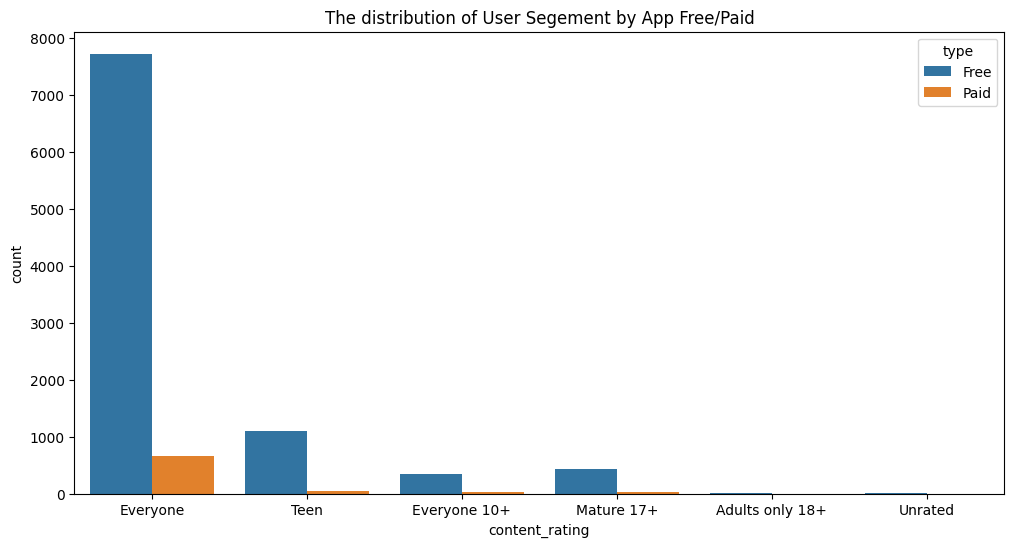

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_play_store_clean, x='content_rating', hue='type')
plt.title('The distribution of User Segement by App Free/Paid')
plt.show()

1. Summary:
- Everyone category dominates the market with the largest number of apps.
- Free apps significantly outnumber paid apps across all categories.
- Paid apps are mainly concentrated in Everyone, while other segments have very low presence.
- Niche segments (Teen, Mature, Adults) remain small in scale.

2. Assumptions:
- Content rating reflects target audience size and accessibility.
- Free model supports user acquisition across broader segments.
- Lower app volume in niche categories indicates smaller demand or stricter regulations.
- Paid apps require stronger value proposition to survive.

3. Insight & Action
Insight 1: Mass market = Everyone category
  + Largest user base but also highest competition.
Action:
  + Enter with strong differentiation or unique value.

Insight 2: Free model dominates across all segments
  + Free apps are the default strategy for scale.
Action:
  + Use free + monetization (ads, in-app purchase) as core model.

Insight 3: Paid apps have limited presence outside mass market
  + Paid model is weak in niche or restricted categories.
Action:
  + Apply paid strategy only with clear, high-value offering.

Insight 4: Niche segments = lower competition but smaller scale
  + Teen and Mature categories are less crowded but limited in size.
Action:
  + Target these segments only with focused positioning and clear audience fit.

In [48]:
merged_df.head(5)

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,...,current_ver,android_ver,month,year,size_group,size_bucket,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,1.0,2018.0,>100MB,>100MB,A kid's excessive ads. The types ads allowed a...,Negative,-0.250000,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,1.0,2018.0,>100MB,>100MB,It bad >:(,Negative,-0.725000,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,1.0,2018.0,>100MB,>100MB,like,Neutral,0.000000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,1.0,2018.0,>100MB,>100MB,No Comment,No Comment,0.182146,0.492704
4,Coloring book moana,ART_AND_DESIGN,3.9,967,1400000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,...,2.0.0,4.0.3 and up,1.0,2018.0,>100MB,>100MB,I love colors inspyering,Positive,0.500000,0.600000


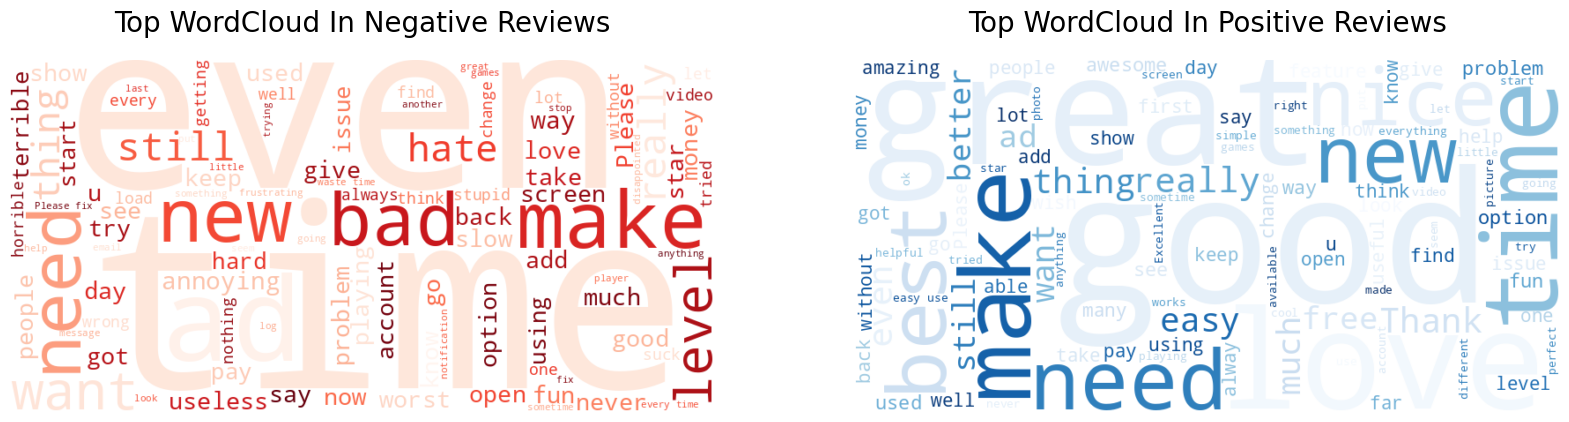

<Figure size 1500x800 with 0 Axes>

In [49]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

neg_reviews = df_user_review_clean[df_user_review_clean['sentiment'] == 'Negative']['translated_review'].dropna()
positive_reviews = df_user_review_clean[df_user_review_clean['sentiment'] == 'Positive']['translated_review'].dropna()


neg_text_data = " ".join(review for review in neg_reviews)
pos_text_data = " ".join(review for review in positive_reviews)


my_stopwords = set(STOPWORDS)
my_stopwords.update(["app", "game", "google", "play", "store", "phone", "work", "update"])


neg_wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=my_stopwords,
        max_words=100,
        colormap='Reds',
        min_font_size=10,
        random_state=42
    ).generate(neg_text_data)

pos_wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=my_stopwords,
        max_words=100,
        colormap='Blues',
        min_font_size=10,
        random_state=42
    ).generate(pos_text_data)

    # 4. Hiển thị bằng Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plt.figure(figsize=(15, 8))

axes[0].imshow(neg_wordcloud, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title("Top WordCloud In Negative Reviews", fontsize=20, pad=20)

axes[1].imshow(pos_wordcloud, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title("Top WordCloud In Positive Reviews", fontsize=20, pad=20)

plt.show()


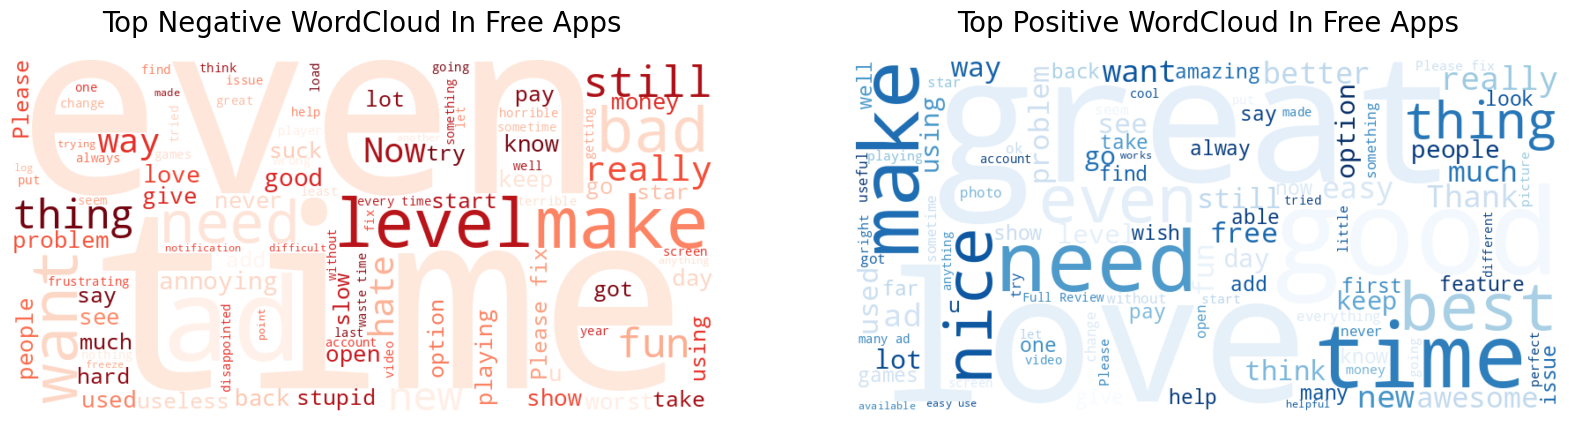

In [50]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

merged_df_free = merged_df[merged_df['type'] == 'Free']

neg_text_free = " ".join(review for review in merged_df_free[merged_df_free['sentiment'] == 'Negative']['translated_review'].dropna())
pos_text_free = " ".join(review for review in merged_df_free[merged_df_free['sentiment'] == 'Positive']['translated_review'].dropna())

my_stopwords = set(STOPWORDS)
my_stopwords.update(["app", "game", "google", "play", "store", "phone", "work", "update"])

neg_free_wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=my_stopwords,
        max_words=100,
        colormap='Reds',
        min_font_size=10,
        random_state=42
    ).generate(neg_text_free)

pos_free_wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=my_stopwords,
        max_words=100,
        colormap='Blues',
        min_font_size=10,
        random_state=42
    ).generate(pos_text_free)


fig, axes = plt.subplots(1, 2, figsize=(20, 8))


axes[0].imshow(neg_free_wordcloud, interpolation='bilinear')
axes[0].axis("off")
axes[0].set_title("Top Negative WordCloud In Free Apps", fontsize=20, pad=20)

axes[1].imshow(pos_free_wordcloud, interpolation='bilinear')
axes[1].axis("off")
axes[1].set_title("Top Positive WordCloud In Free Apps", fontsize=20, pad=20)

plt.show()


1. Summary:
- Positive reviews focus on basic satisfaction (e.g. great, good, nice).
- Negative reviews are more extreme and emotional (e.g. worst, horrible, useless).
- “Disappointed” stands out => clear expectation vs reality gap.
- Complaints focus more on product quality than ads.

2. Assumptions:
- Word frequency reflects key drivers of user perception.
- Free users have low entry barrier but high sensitivity to experience.
- Expectations are influenced by marketing and app positioning.
- Absence of “ads” suggests ads are not the main pain point in this dataset.

3. Insight & Action:
Insight 1: Free users reward basic functionality
  + Users give positive feedback when app simply works well.
Action:
  + Ensure core features are reliable and smooth.

Insight 2: Negative feedback is driven by value failure
  + Words like “useless” indicate failure to deliver core value.
Action:
  + Prioritize solving real user problems, not just adding features.

Insight 3: Expectation gap is a key risk
  + “Disappointed” shows mismatch between promise and actual experience.
Action:
  + Align marketing message with real product capability.

Insight 4: Ads are not the main issue
  + Users complain more about quality than monetization.
Action:
  + Optimize product experience first, then scale monetization.